# FNO-Specific Input Channel Design

## Why the CNN physics channels are suboptimal for FNO

The baseline used:
| Channel | Transform | Why it helped CNN |
|---|---|---|
| Ch 0 | Raw image | Absolute flux |
| Ch 1 | Gradient magnitude | Edges — CNNs struggle to build these from scratch |
| Ch 2 | Laplacian | Blob detection — CNNs need many layers for 2nd derivatives |

These helped ConvNeXt because **CNNs learn local filters** — giving them pre-computed edges/blobs saves layers.

FNO does NOT need these. FNO's spectral conv already learns arbitrary frequency filters globally in one layer.
Feeding gradient magnitude = doing FNO's job for it, then giving it redundant output.

## What FNO actually benefits from

FNO lifts spatial input into latent frequency space. The most useful extra channels are ones that provide:
1. **Spectral amplitude** — global power distribution the FNO can condition on
2. **Phase information** — ring/arc orientation that is hard to recover from amplitude alone  
3. **Radial symmetry prior** — lensing rings are radially symmetric; breaking this out explicitly helps


## New 4-Channel FNO Dataset

In [1]:
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

class LensDatasetFNO(Dataset):
    """
    FNO-optimised 4-channel input:

    Ch 0 — Raw image             (spatial flux, same as baseline)
    Ch 1 — Log power spectrum    (global spectral energy distribution)
    Ch 2 — Phase coherence map   (ring/arc orientation structure)
    Ch 3 — Radial symmetry       (deviation from perfect Einstein ring)

    Rationale
    ---------
    Ch 1: FNO's first operation is rfft2. Providing log|FFT|^2 directly
          gives the spectral conv a pre-computed frequency prior to condition
          on — instead of deriving it from raw pixels each forward pass.

    Ch 2: Phase carries the angular structure of arcs and rings. CNNs ignore
          phase (they learn magnitude features). FNO can USE phase directly
          since it operates in complex frequency space.

    Ch 3: Lensing rings are radially symmetric. Substructure BREAKS that
          symmetry. This channel encodes deviation from rotational symmetry —
          the exact signal that separates the three classes. It is a global
          feature that CNN channels (gradient, Laplacian) don't capture well.
    """

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.paths, self.labels = [], []
        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        for cls in self.classes:
            for f in os.listdir(os.path.join(root_dir, cls)):
                if f.endswith(".npy"):
                    self.paths.append(os.path.join(root_dir, cls, f))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.paths)

    # ── Channel builders ─────────────────────────────────────────────────────

    def log_power_spectrum(self, img):
        """
        Ch 1: log(1 + |FFT(img)|^2) mapped back to spatial domain via irfft2.

        Why: Provides FNO with the global spectral energy distribution as
        spatial context. Subhalo substructure concentrates power at specific
        mid-frequencies; vortex redistributes angular power. This channel
        makes those differences explicit at the input level.

        irfft2 maps it back to 150x150 so it stays compatible with the
        spatial lifting conv that precedes the FNO blocks.
        """
        eps = 1e-8
        ft  = torch.fft.rfft2(img[0], norm="ortho")          # complex (H, W//2+1)
        log_psd = torch.log1p(ft.abs()**2 + eps)              # real, same shape
        # reconstruct spatial field from the log-PSD (treat as real spectrum)
        log_psd_spatial = torch.fft.irfft2(
            torch.complex(log_psd, torch.zeros_like(log_psd)),
            s=(img.shape[-2], img.shape[-1]), norm="ortho")   # (H, W)
        # normalise to [0, 1]
        lp = log_psd_spatial.abs()
        return ((lp - lp.min()) / (lp.max() - lp.min() + eps)).unsqueeze(0)

    def phase_coherence(self, img):
        """
        Ch 2: Spatial map of local phase coherence.

        The Einstein ring creates a coherent circular phase pattern in the
        Fourier domain. Substructure BREAKS this coherence locally.

        Method: compute the phase angle of FFT, then irfft2 the phase-only
        spectrum (unit magnitude). The resulting spatial field encodes where
        phase is coherent (ring) vs disrupted (substructure).
        """
        eps = 1e-8
        ft    = torch.fft.rfft2(img[0], norm="ortho")
        mag   = ft.abs().clamp(min=eps)
        phase_only = ft / mag                                  # unit complex
        spatial    = torch.fft.irfft2(phase_only,
                                       s=(img.shape[-2], img.shape[-1]),
                                       norm="ortho")
        sp = spatial.abs()
        return ((sp - sp.min()) / (sp.max() - sp.min() + eps)).unsqueeze(0)

    def radial_symmetry(self, img):
        """
        Ch 3: Deviation from radial symmetry.

        Perfect Einstein ring (no_sub) is radially symmetric.
        Subhalo/vortex BREAK symmetry. This channel is:
            deviation(r, theta) = |I(r, theta) - mean_theta[I(r, theta)]|

        i.e. how much each pixel deviates from the angular mean at its radius.
        Strong response = substructure location.
        Strong ring-wide response = vortex (distributed).
        Localised strong response = subhalo (localised).
        """
        eps  = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = W / 2.0, H / 2.0

        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii = torch.sqrt((xs - cx)**2 + (ys - cy)**2)      # (H, W)

        # bin into 30 radial rings
        n_bins   = 30
        r_max    = radii.max()
        bin_idx  = (radii / (r_max + eps) * n_bins).long().clamp(0, n_bins - 1)  # (H, W)

        I = img[0]                                             # (H, W)
        deviation = torch.zeros_like(I)
        for b in range(n_bins):
            mask = (bin_idx == b)
            if mask.sum() > 0:
                ring_mean = I[mask].mean()
                deviation[mask] = (I[mask] - ring_mean).abs()

        return ((deviation - deviation.min()) / (deviation.max() - deviation.min() + eps)).unsqueeze(0)

    def __getitem__(self, idx):
        image = torch.tensor(np.load(self.paths[idx]), dtype=torch.float32)
        if image.ndim == 2: image = image.unsqueeze(0)        # (1, H, W)

        ch0 = image                                            # raw
        ch1 = self.log_power_spectrum(image)                   # log PSD (spatial)
        ch2 = self.phase_coherence(image)                      # phase coherence
        ch3 = self.radial_symmetry(image)                      # symmetry deviation

        combined = torch.cat([ch0, ch1, ch2, ch3], dim=0)     # (4, H, W)
        if self.transform: combined = self.transform(combined)
        return combined, self.labels[idx]


## Why each channel is non-redundant for FNO

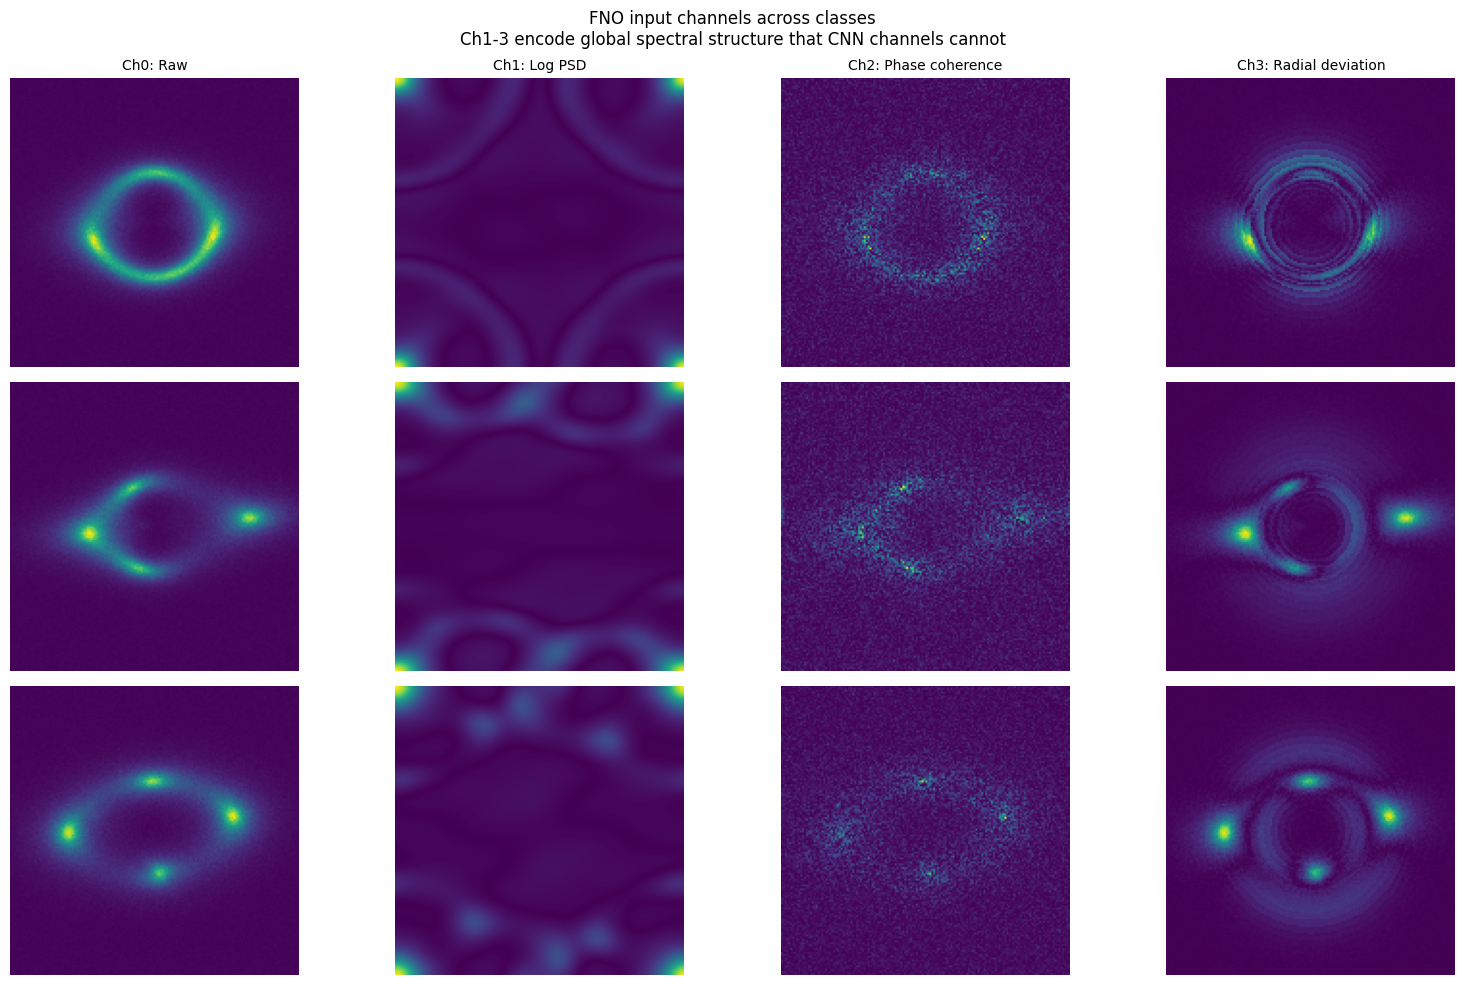

Key observations:
Ch1 (Log PSD): power distribution differs between classes — vortex shows ring-mode concentration
Ch2 (Phase  ): coherence breaks at substructure location — localised for subhalo, ring-wide for vortex
Ch3 (Radial ): near-zero for no_sub (symmetric ring), strong for subhalo/vortex (broken symmetry)


In [3]:
# Visualise all 4 channels across the 3 classes
import matplotlib.pyplot as plt

dataset_viz = LensDatasetFNO("dataset/train")
class_names = ['no_sub', 'subhalo', 'vortex']
ch_names    = ['Ch0: Raw', 'Ch1: Log PSD', 'Ch2: Phase coherence', 'Ch3: Radial deviation']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for class_idx in range(3):
    idx = dataset_viz.labels.index(class_idx)
    img, _ = dataset_viz[idx]           # (4, H, W), before transform

    for ch in range(4):
        ax = axes[class_idx][ch]
        ax.imshow(img[ch].numpy(), cmap='viridis')
        if class_idx == 0: ax.set_title(ch_names[ch], fontsize=10)
        if ch == 0:        ax.set_ylabel(class_names[class_idx], fontsize=11)
        ax.axis('off')

plt.suptitle('FNO input channels across classes\n'
             'Ch1-3 encode global spectral structure that CNN channels cannot', fontsize=12)
plt.tight_layout()
plt.show()

print("Key observations:")
print("Ch1 (Log PSD): power distribution differs between classes — vortex shows ring-mode concentration")
print("Ch2 (Phase  ): coherence breaks at substructure location — localised for subhalo, ring-wide for vortex")
print("Ch3 (Radial ): near-zero for no_sub (symmetric ring), strong for subhalo/vortex (broken symmetry)")


## Compute channel statistics for normalisation

In [4]:
def compute_channel_stats(dataset, n_channels=4):
    s1 = torch.zeros(n_channels); s2 = torch.zeros(n_channels); n = 0
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
    for imgs, _ in loader:
        s1 += imgs.sum(dim=[0,2,3])
        s2 += (imgs**2).sum(dim=[0,2,3])
        n  += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]
    mean = s1 / n
    std  = torch.sqrt(s2/n - mean**2).clamp(min=0.0005)
    return mean.tolist(), std.tolist()

train_ds_raw = LensDatasetFNO("dataset/train")
MEAN_FNO, STD_FNO = compute_channel_stats(train_ds_raw, n_channels=4)
print("FNO channel means:", [f'{m:.4f}' for m in MEAN_FNO])
print("FNO channel stds :", [f'{s:.4f}' for s in STD_FNO])


FNO channel means: ['0.0617', '0.0485', '0.0596', '0.0420']
FNO channel stds : ['0.1173', '0.0890', '0.0653', '0.0869']


## Build loaders with FNO channels

In [ ]:
IMG_SIZE = 150

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), fill=0),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=MEAN_FNO, std=STD_FNO)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=MEAN_FNO, std=STD_FNO)
])

train_dataset = LensDatasetFNO("dataset/train", transform=train_transform)
val_dataset   = LensDatasetFNO("dataset/val",   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Input shape: {train_dataset[0][0].shape}")   # (4, 150, 150)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")


## Update FNOClassifier for 4-channel input

In [ ]:
import torch.nn as nn

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.out_channels = out_channels
        self.modes1, self.modes2 = modes1, modes2
        scale = 1.0 / (in_channels * out_channels)
        self.wr1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2))
        self.wi1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2))
        self.wr2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2))
        self.wi2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2))

    def _cmul(self, xr, xi, wr, wi):
        return (torch.einsum("bixy,ioxy->boxy", xr, wr) - torch.einsum("bixy,ioxy->boxy", xi, wi),
                torch.einsum("bixy,ioxy->boxy", xr, wi) + torch.einsum("bixy,ioxy->boxy", xi, wr))

    def forward(self, x):
        B, C, H, W = x.shape
        ft = torch.fft.rfft2(x, norm="ortho")
        fr, fi = ft.real, ft.imag
        or_ = torch.zeros(B, self.out_channels, H, W//2+1, device=x.device)
        oi  = torch.zeros_like(or_)
        r1,i1 = self._cmul(fr[:,:,:self.modes1,:self.modes2], fi[:,:,:self.modes1,:self.modes2], self.wr1, self.wi1)
        or_[:,:,:self.modes1,:self.modes2]=r1; oi[:,:,:self.modes1,:self.modes2]=i1
        r2,i2 = self._cmul(fr[:,:,-self.modes1:,:self.modes2], fi[:,:,-self.modes1:,:self.modes2], self.wr2, self.wi2)
        or_[:,:,-self.modes1:,:self.modes2]=r2; oi[:,:,-self.modes1:,:self.modes2]=i2
        return torch.fft.irfft2(torch.complex(or_, oi), s=(H, W), norm="ortho")

class FNOBlock2d(nn.Module):
    def __init__(self, channels, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(channels, channels, modes1, modes2)
        self.bypass   = nn.Conv2d(channels, channels, 1)
        self.norm     = nn.InstanceNorm2d(channels, affine=True)
    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.bypass(x)))

class FNOClassifier(nn.Module):
    def __init__(self, in_channels=4, width=64, modes1=20, modes2=20,   # <- 4 channels now
                 depth=4, num_classes=3, dropout=0.3):
        super().__init__()
        self.lift = nn.Sequential(
            nn.Conv2d(in_channels, width, 3, padding=1),
            nn.InstanceNorm2d(width, affine=True), nn.GELU())
        self.fno_blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        proj_ch = width * 2
        self.project = nn.Sequential(nn.Conv2d(width, proj_ch, 1), nn.BatchNorm2d(proj_ch), nn.GELU())
        self.gap = nn.AdaptiveAvgPool2d(1); self.gmp = nn.AdaptiveMaxPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(proj_ch*2, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.lift(x)
        for blk in self.fno_blocks: x = blk(x)
        x = self.project(x)
        return self.head(torch.cat([self.gap(x), self.gmp(x)], dim=1))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FNOClassifier(in_channels=4)   # 4-channel FNO input
dummy = torch.randn(2, 4, 150, 150)
print(f"Output: {model(dummy).shape}  | Params: {model.count_parameters():,}")
